## 1. k space only

In [ ]:
from __future__ import annotations
import argparse
from dataclasses import dataclass
from pathlib import Path
from typing import List, Tuple

import numpy as np
import h5py, nibabel as nib
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torch.cuda.amp import GradScaler, autocast
from torch.optim import Adam
from tqdm import tqdm

# ------------------------------------------------------------------------------
# 1. utils
# ------------------------------------------------------------------------------
def center_crop_or_pad(arr: np.ndarray, target: Tuple[int, int]) -> np.ndarray:
    H, W = arr.shape
    th, tw = target
    out = np.zeros(target, dtype=arr.dtype)
    h0s, w0s = max((H - th) // 2, 0), max((W - tw) // 2, 0)
    h0d, w0d = max((th - H) // 2, 0), max((tw - W) // 2, 0)
    hlen, wlen = min(th, H), min(tw, W)
    out[h0d:h0d + hlen, w0d:w0d + wlen] = arr[h0s:h0s + hlen, w0s:w0s + wlen]
    return out


def resize_kspace_complex(k: np.ndarray, target: Tuple[int, int]) -> np.ndarray:
    if k.ndim == 2:
        k = k[None]
    C, H, W = k.shape
    th, tw = target
    out = np.zeros((C, th, tw), k.dtype)
    h0s, w0s = max((H - th) // 2, 0), max((W - tw) // 2, 0)
    h0d, w0d = max((th - H) // 2, 0), max((tw - W) // 2, 0)
    hlen, wlen = min(th, H), min(tw, W)
    out[:, h0d:h0d + hlen, w0d:w0d + wlen] = k[:, h0s:h0s + hlen, w0s:w0s + wlen]
    return out

def ifft2c_torch(x: torch.Tensor) -> torch.Tensor:
    return torch.fft.ifftshift(
        torch.fft.ifft2(torch.fft.ifftshift(x, dim=(-2, -1)), norm="ortho"),
        dim=(-2, -1),
    )


def chan_to_complex(x: torch.Tensor) -> torch.Tensor:
    assert x.size(-3) == 2, "Expect RI channels"
    return torch.complex(x.select(-3, 0), x.select(-3, 1))

# ------------------------------------------------------------------------------
# 2. Dataset
# ------------------------------------------------------------------------------
class CineSegDataset(Dataset):
    def __init__(
        self,
        root: Path,
        cases: List[str],
        frames: Tuple[int, ...],
        target_shape: Tuple[int, int],
        num_coil: int = 1,
        n_classes: int = 4,
    ):
        self.samples, self.tshape = [], target_shape
        self.num_coil, self.ncls = num_coil, n_classes

        for cid in cases:
            kf   = root / f"FullSample/{cid}/cine_sax.mat"
            labf = root / f"SegmentROI/{cid}/cine_sax_label.nii.gz"
            if not (kf.exists() and labf.exists()):
                continue
            with h5py.File(kf) as h:
                k_ds = h["kspace_single_full"]
                n_k  = k_ds.shape[1] if k_ds.ndim == 4 else k_ds.shape[0]
            n_lab = nib.load(str(labf)).shape[2]
            if n_k != n_lab: 
                continue
            for f in frames:
                if f < n_k:
                    self.samples.append((kf, labf, f))
        print(f"Seg dataset size: {len(self.samples)} slices.")

    def __len__(self): return len(self.samples)

    def __getitem__(self, idx):
        kfile, labfile, f = self.samples[idx]

        # ----- k‑space -----
        with h5py.File(kfile) as h:
            k = h["kspace_single_full"][()]
            if k.dtype.names:
                k = k["real"] + 1j * k["imag"]
        k = k[f] if k.ndim == 3 else k[:, f]
        k = k[: self.num_coil]
        k_rs = resize_kspace_complex(k, self.tshape)

        scale = np.abs(k_rs).max() + 1e-8
        k_ri = (
            np.stack([k_rs.real / scale, k_rs.imag / scale], 1)
            .reshape(-1, *self.tshape)
            .astype(np.float32)
        )
        k_ri = torch.from_numpy(k_ri)

        # ----- segmentation -----
        seg = nib.load(str(labfile)).get_fdata()[:, :, f].T.astype(np.int16)
        seg = center_crop_or_pad(seg, self.tshape)
        seg[seg >= self.ncls] = 0
        seg = torch.from_numpy(seg).long()

        return k_ri, seg

# ------------------------------------------------------------------------------
# 3. Network blocks
# ------------------------------------------------------------------------------
class SweepGRU(nn.Module):
    def __init__(self, in_ch, hidden, axis):
        super().__init__()
        assert axis in (-1, -2)
        self.axis = axis
        self.hidden = hidden
        self.gru = nn.GRU(in_ch, hidden, batch_first=True, bidirectional=True)
        # forget gate bias init
        for n, p in self.gru.named_parameters():
            if "bias" in n:
                nn.init.constant_(p[hidden:2*hidden], 1.0)

    def forward(self, x):
        B, C, H, W = x.shape
        if self.axis == -1:          # width
            t = x.permute(0, 2, 3, 1).contiguous().view(B*H, W, C)
            o, _ = self.gru(t)
            return o.view(B, H, W, -1).permute(0, 3, 1, 2)
        else:                        # height
            t = x.permute(0, 3, 2, 1).contiguous().view(B*W, H, C)
            o, _ = self.gru(t)
            return o.view(B, W, H, -1).permute(0, 3, 2, 1)


class KspaceRNNEncoder(nn.Module):
    def __init__(self, in_ch, nf=32, fuse="concat"):
        super().__init__()
        self.fuse = fuse
        self.horz = SweepGRU(in_ch, nf, axis=-1)
        self.vert = SweepGRU(in_ch, nf, axis=-2)
        if fuse == "add":
            self.post = nn.Identity()
            self.out_ch = nf * 2
        else:
            self.post = nn.Conv2d(nf * 4, nf * 2, 1)
            self.out_ch = nf * 2

    def forward(self, x):
        h1, h2 = self.horz(x), self.vert(x)
        h = h1 + h2 if self.fuse == "add" else torch.cat([h1, h2], 1)
        return self.post(h)

class CoarseHead(nn.Module):
    def __init__(self, in_ch):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(in_ch, in_ch, 3, padding=1), nn.ReLU(True),
            nn.Conv2d(in_ch, 1, 1)
        )
    def forward(self, x): return self.net(x)

class ConvBlock(nn.Module):
    def __init__(self, in_ch, out_ch, use_in=True):
        super().__init__()
        norm = (lambda c: nn.InstanceNorm2d(c)) if use_in else (lambda c: nn.Identity())
        self.block = nn.Sequential(
            nn.Conv2d(in_ch, out_ch, 3, padding=1), norm(out_ch), nn.ReLU(True),
            nn.Conv2d(out_ch, out_ch, 3, padding=1), norm(out_ch), nn.ReLU(True),
        )
    def forward(self, x): return self.block(x)

class UpBlock(nn.Module):
    def __init__(self, in_ch, out_ch, use_in=True):
        super().__init__()
        self.up = nn.Upsample(scale_factor=2, mode="bilinear", align_corners=False)
        self.conv = ConvBlock(in_ch, out_ch, use_in)
    def forward(self, x, skip):
        x = self.up(x)
        dh, dw = skip.size(-2) - x.size(-2), skip.size(-1) - x.size(-1)
        if dh or dw: x = F.pad(x, (0, dw, 0, dh))
        return self.conv(torch.cat([x, skip], 1))

class UNet(nn.Module):
    def __init__(self, in_ch, out_ch=1, base=32, use_in=True, num_pool=4):
        super().__init__()
        chs, self.pools, self.downs = [], nn.ModuleList(), nn.ModuleList()
        prev = in_ch
        for i in range(num_pool):
            c = base * 2 ** i
            self.downs.append(ConvBlock(prev, c, use_in))
            self.pools.append(nn.MaxPool2d(2))
            chs.append(c)
            prev = c
        self.bottleneck = ConvBlock(prev, prev * 2, use_in)
        prev = prev * 2
        self.ups = nn.ModuleList()
        for c in reversed(chs):
            self.ups.append(UpBlock(prev + c, c, use_in))
            prev = c
        self.final = nn.Conv2d(prev, out_ch, 1)

    def forward(self, x):
        skips, h = [], x
        for d, p in zip(self.downs, self.pools):
            h = d(h); skips.append(h); h = p(h)
        h = self.bottleneck(h)
        for up, sk in zip(self.ups, reversed(skips)):
            h = up(h, sk)
        return self.final(h)

# ------------------------------------------------------------------------------
# 4. Seg model
# ------------------------------------------------------------------------------
@dataclass
class ModelCfg:
    in_ch: int = 2
    nf: int = 32
    num_classes: int = 4
    unet_base: int = 32
    use_in: bool = True

class ReconSegModel0(nn.Module):
    def __init__(self, cfg: ModelCfg):
        super().__init__()
        self.enc    = KspaceRNNEncoder(cfg.in_ch, cfg.nf, "concat")
        self.coarse = CoarseHead(self.enc.out_ch)
        self.refiner= UNet(1, cfg.num_classes, base=cfg.unet_base, use_in=cfg.use_in)
        self.apply(self._init_weights)
    @staticmethod
    def _init_weights(m):
        if isinstance(m, (nn.Conv2d, nn.ConvTranspose2d)):
            nn.init.kaiming_normal_(m.weight, nonlinearity="relu")
            if m.bias is not None: nn.init.zeros_(m.bias)

    def forward(self, k_ri):           # return logits
        coarse = self.coarse(self.enc(k_ri))
        return self.refiner(coarse)

    def loss(self, logits, mask):
        ce = F.cross_entropy(logits, mask)
        with torch.no_grad():
            pred = logits.argmax(1)
            dice = (pred == mask).float().mean()  # overall acc
        return {"ce": ce, "dice": 1 - dice, "total": ce}

# ------------------------------------------------------------------------------
# 5. metrics
# ------------------------------------------------------------------------------
@torch.no_grad()
def metric_mIoU(logits: torch.Tensor, mask: torch.Tensor) -> float:
    pred = logits.argmax(1)
    miou_tot, classes = 0.0, 0
    for c in range(logits.size(1)):
        inter = ((pred == c) & (mask == c)).sum()
        union = ((pred == c) | (mask == c)).sum()
        if union == 0: continue
        miou_tot += (inter / union).item()
        classes += 1
    return miou_tot / max(classes, 1)

# ------------------------------------------------------------------------------
# 6. trainer
# ------------------------------------------------------------------------------
class Trainer:
    def __init__(self, model, train_loader, val_loader, lr, out_dir: Path, dev):
        self.model, self.train_loader, self.val_loader = model.to(dev), train_loader, val_loader
        self.opt, self.scaler, self.dev = Adam(model.parameters(), lr), GradScaler(), dev
        self.best = 0.0; self.out_dir = out_dir

    def train_epoch(self, epoch):
        self.model.train()
        pbar = tqdm(self.train_loader, desc=f"Train {epoch}")
        tot, cnt = 0.0, 0
        for k, seg in pbar:
            k, seg = k.to(self.dev), seg.to(self.dev)
            self.opt.zero_grad(set_to_none=True)
            with autocast():
                logits = self.model(k); losses = self.model.loss(logits, seg)
            self.scaler.scale(losses["total"]).backward()
            self.scaler.step(self.opt); self.scaler.update()
            bsz = k.size(0); tot += losses["ce"].item()*bsz; cnt += bsz
            pbar.set_postfix(ce=losses["ce"].item(), dice=1-losses["dice"].item())
        print(f"[Epoch {epoch}] CE={tot/cnt:.4e}")

    @torch.no_grad()
    def validate(self, epoch):
        self.model.eval(); miou_sum, cnt = 0.0, 0
        for k, seg in tqdm(self.val_loader, desc="Val"):
            k, seg = k.to(self.dev), seg.to(self.dev)
            logits = self.model(k)
            miou_sum += metric_mIoU(logits, seg) * k.size(0)
            cnt += k.size(0)
        miou = miou_sum / cnt
        print(f"Epoch {epoch}: mIoU={miou:.4f}")
        if miou > self.best:
            self.best = miou
            torch.save(self.model.state_dict(), self.out_dir / "best_seg_22.pt")
        return miou

import matplotlib.pyplot as plt
import torch
import numpy as np

## 2. K space and Image

In [ ]:
from __future__ import annotations
import argparse
from dataclasses import dataclass
from pathlib import Path
from typing import List, Tuple

import numpy as np
import h5py, nibabel as nib
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torch.cuda.amp import GradScaler, autocast
from torch.optim import Adam
from tqdm import tqdm

# ------------------------------------------------------------------------------
# 1. utils
# ------------------------------------------------------------------------------
def center_crop_or_pad(arr: np.ndarray, target: Tuple[int, int]) -> np.ndarray:
    H, W = arr.shape
    th, tw = target
    out = np.zeros(target, dtype=arr.dtype)
    h0s, w0s = max((H - th) // 2, 0), max((W - tw) // 2, 0)
    h0d, w0d = max((th - H) // 2, 0), max((tw - W) // 2, 0)
    hlen, wlen = min(th, H), min(tw, W)
    out[h0d:h0d + hlen, w0d:w0d + wlen] = arr[h0s:h0s + hlen, w0s:w0s + wlen]
    return out


def resize_kspace_complex(k: np.ndarray, target: Tuple[int, int]) -> np.ndarray:
    if k.ndim == 2:
        k = k[None]
    C, H, W = k.shape
    th, tw = target
    out = np.zeros((C, th, tw), k.dtype)
    h0s, w0s = max((H - th) // 2, 0), max((W - tw) // 2, 0)
    h0d, w0d = max((th - H) // 2, 0), max((tw - W) // 2, 0)
    hlen, wlen = min(th, H), min(tw, W)
    out[:, h0d:h0d + hlen, w0d:w0d + wlen] = k[:, h0s:h0s + hlen, w0s:w0s + wlen]
    return out

# ------------------------------------------------------------------------------
# 2. Dataset
# ------------------------------------------------------------------------------
class CineSegDataset(Dataset):
    def __init__(
        self,
        root: Path,
        cases: List[str],
        frames: Tuple[int, ...],
        target_shape: Tuple[int, int],
        num_coil: int = 1,
        n_classes: int = 4,
    ):
        self.samples, self.tshape = [], target_shape
        self.num_coil, self.ncls = num_coil, n_classes

        for cid in cases:
            kf   = root / f"FullSample/{cid}/cine_sax.mat"
            labf = root / f"SegmentROI/{cid}/cine_sax_label.nii.gz"
            if not (kf.exists() and labf.exists()):
                continue
            with h5py.File(kf) as h:
                k_ds = h["kspace_single_full"]
                n_k  = k_ds.shape[1] if k_ds.ndim == 4 else k_ds.shape[0]
            n_lab = nib.load(str(labf)).shape[2]
            if n_k != n_lab:    
                continue
            for f in frames:
                if f < n_k:
                    self.samples.append((kf, labf, f))
        print(f"Seg dataset size: {len(self.samples)} slices.")

    def __len__(self): return len(self.samples)

    def __getitem__(self, idx):
        kfile, labfile, f = self.samples[idx]

        # ----- k‑space -----
        with h5py.File(kfile) as h:
            k = h["kspace_single_full"][()]
            if k.dtype.names:   
                k = k["real"] + 1j * k["imag"]
        k = k[f] if k.ndim == 3 else k[:, f]
        k = k[: self.num_coil]
        k_rs = resize_kspace_complex(k, self.tshape)

        scale = np.abs(k_rs).max() + 1e-8
        k_ri = (
            np.stack([k_rs.real / scale, k_rs.imag / scale], 1)
            .reshape(-1, *self.tshape)
            .astype(np.float32)
        )
        k_ri = torch.from_numpy(k_ri)

        # ----- segmentation -----
        seg = nib.load(str(labfile)).get_fdata()[:, :, f].T.astype(np.int16)
        seg = center_crop_or_pad(seg, self.tshape)
        seg[seg >= self.ncls] = 0
        seg = torch.from_numpy(seg).long()

        return k_ri, seg

# ------------------------------------------------------------------------------
# 3. Network blocks
# ------------------------------------------------------------------------------
class SweepGRU_2(nn.Module):
    def __init__(self, in_ch, hidden, axis, num_layers: int = 3, residual: bool = True):
        super().__init__()
        assert axis in (-1, -2)
        self.axis, self.residual = axis, residual

        self.layers = nn.ModuleList([
            nn.GRU(
                input_size=in_ch if i == 0 else hidden * 2,
                hidden_size=hidden,
                num_layers=1,
                batch_first=True,
                bidirectional=True
            )
            for i in range(num_layers)
        ])

        # forget‑gate bias init
        for gru in self.layers:
            for name, p in gru.named_parameters():
                if "bias" in name:
                    nn.init.constant_(p[hidden:2 * hidden], 1.0)

    def _sweep(self, t: torch.Tensor):
        out = t
        for gru in self.layers:
            out, _ = gru(out)
            if self.residual and out.shape == t.shape:
                out = out + t      
            t = out    
        return out

    def forward(self, x):
        B, C, H, W = x.shape
        if self.axis == -1:            # width sweep
            t = x.permute(0, 2, 3, 1).contiguous().view(B * H, W, C)
            o = self._sweep(t)
            return o.view(B, H, W, -1).permute(0, 3, 1, 2)
        else:                          # height sweep
            t = x.permute(0, 3, 2, 1).contiguous().view(B * W, H, C)
            o = self._sweep(t)
            return o.view(B, W, H, -1).permute(0, 3, 2, 1)


class KspaceRNNEncoder(nn.Module):
    def __init__(self, in_ch, nf=32, fuse="concat"):
        super().__init__()
        self.fuse = fuse
        self.horz = SweepGRU(in_ch, nf, axis=-1)
        self.vert = SweepGRU(in_ch, nf, axis=-2)
        if fuse == "add":
            self.post = nn.Identity()
            self.out_ch = nf * 2
        else:
            self.post = nn.Conv2d(nf * 4, nf * 2, 1)
            self.out_ch = nf * 2

    def forward(self, x):
        h1, h2 = self.horz(x), self.vert(x)
        h = h1 + h2 if self.fuse == "add" else torch.cat([h1, h2], 1)
        return self.post(h)

class CoarseHead(nn.Module):
    def __init__(self, in_ch):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(in_ch, in_ch, 3, padding=1), nn.ReLU(True),
            nn.Conv2d(in_ch, 1, 1)
        )
    def forward(self, x): return self.net(x)

class ConvBlock(nn.Module):
    def __init__(self, in_ch, out_ch, use_in=True):
        super().__init__()
        norm = (lambda c: nn.InstanceNorm2d(c)) if use_in else (lambda c: nn.Identity())
        self.block = nn.Sequential(
            nn.Conv2d(in_ch, out_ch, 3, padding=1), norm(out_ch), nn.ReLU(True),
            nn.Conv2d(out_ch, out_ch, 3, padding=1), norm(out_ch), nn.ReLU(True),
        )
    def forward(self, x): return self.block(x)

class UpBlock(nn.Module):
    def __init__(self, in_ch, out_ch, use_in=True):
        super().__init__()
        self.up = nn.Upsample(scale_factor=2, mode="bilinear", align_corners=False)
        self.conv = ConvBlock(in_ch, out_ch, use_in)
    def forward(self, x, skip):
        x = self.up(x)
        dh, dw = skip.size(-2) - x.size(-2), skip.size(-1) - x.size(-1)
        if dh or dw: x = F.pad(x, (0, dw, 0, dh))
        return self.conv(torch.cat([x, skip], 1))

class UNet(nn.Module):
    def __init__(self, in_ch, out_ch=1, base=32, use_in=True, num_pool=4):
        super().__init__()
        chs, self.pools, self.downs = [], nn.ModuleList(), nn.ModuleList()
        prev = in_ch
        for i in range(num_pool):
            c = base * 2 ** i
            self.downs.append(ConvBlock(prev, c, use_in))
            self.pools.append(nn.MaxPool2d(2))
            chs.append(c)
            prev = c
        self.bottleneck = ConvBlock(prev, prev * 2, use_in)
        prev = prev * 2
        self.ups = nn.ModuleList()
        for c in reversed(chs):
            self.ups.append(UpBlock(prev + c, c, use_in))
            prev = c
        self.final = nn.Conv2d(prev, out_ch, 1)

    def forward(self, x):
        skips, h = [], x
        for d, p in zip(self.downs, self.pools):
            h = d(h); skips.append(h); h = p(h)
        h = self.bottleneck(h)
        for up, sk in zip(self.ups, reversed(skips)):
            h = up(h, sk)
        return self.final(h)

# ------------------------------------------------------------------------------
# 4. Seg model
# ------------------------------------------------------------------------------
@dataclass
class ModelCfg_2:
    in_ch: int = 2
    nf: int = 32
    num_classes: int = 4
    unet_base: int = 32
    use_in: bool = True

class ReconSegModel2(nn.Module):
    def __init__(self, cfg: ModelCfg_2):
        super().__init__()
        self.enc    = KspaceRNNEncoder(cfg.in_ch, cfg.nf, "concat")
        self.coarse = CoarseHead(self.enc.out_ch)
        self.refiner= UNet(2, cfg.num_classes, base=cfg.unet_base, use_in=cfg.use_in)
        self.apply(self._init_weights)
    @staticmethod
    def _init_weights(m):
        if isinstance(m, (nn.Conv2d, nn.ConvTranspose2d)):
            nn.init.kaiming_normal_(m.weight, nonlinearity="relu")
            if m.bias is not None: nn.init.zeros_(m.bias)

    def forward(self, k_ri):           # return logits
        coarse = self.coarse(self.enc(k_ri))
        img_zf = ifft2c_torch(chan_to_complex(k_ri)).abs().unsqueeze(1)
        ref_in = torch.cat([coarse, img_zf], 1)
        return self.refiner(ref_in)

    def loss(self, logits, mask):
        ce = F.cross_entropy(logits, mask)
        with torch.no_grad():
            pred = logits.argmax(1)
            dice = (pred == mask).float().mean()  # overall acc
        return {"ce": ce, "dice": 1 - dice, "total": ce}

# ------------------------------------------------------------------------------
# 5. metrics
# ------------------------------------------------------------------------------
@torch.no_grad()
def metric_mIoU(logits: torch.Tensor, mask: torch.Tensor) -> float:
    pred = logits.argmax(1)
    miou_tot, classes = 0.0, 0
    for c in range(logits.size(1)):
        inter = ((pred == c) & (mask == c)).sum()
        union = ((pred == c) | (mask == c)).sum()
        if union == 0: continue
        miou_tot += (inter / union).item()
        classes += 1
    return miou_tot / max(classes, 1)

# ------------------------------------------------------------------------------
# 6. trainer
# ------------------------------------------------------------------------------
class Trainer:
    def __init__(self, model, train_loader, val_loader, lr, out_dir: Path, dev):
        self.model, self.train_loader, self.val_loader = model.to(dev), train_loader, val_loader
        self.opt, self.scaler, self.dev = Adam(model.parameters(), lr), GradScaler(), dev
        self.best = 0.0; self.out_dir = out_dir

    def train_epoch(self, epoch):
        self.model.train()
        pbar = tqdm(self.train_loader, desc=f"Train {epoch}")
        tot, cnt = 0.0, 0
        for k, seg in pbar:
            k, seg = k.to(self.dev), seg.to(self.dev)
            self.opt.zero_grad(set_to_none=True)
            with autocast():
                logits = self.model(k); losses = self.model.loss(logits, seg)
            self.scaler.scale(losses["total"]).backward()
            self.scaler.step(self.opt); self.scaler.update()
            bsz = k.size(0); tot += losses["ce"].item()*bsz; cnt += bsz
            pbar.set_postfix(ce=losses["ce"].item(), dice=1-losses["dice"].item())
        print(f"[Epoch {epoch}] CE={tot/cnt:.4e}")

    @torch.no_grad()
    def validate(self, epoch):
        self.model.eval()
        miou_sum, ce_sum, count = 0.0, 0.0, 0

        for k, seg in tqdm(self.val_loader, desc="Val"):
            k, seg = k.to(self.dev), seg.to(self.dev)
            logits = self.model(k)
            loss_dict = self.model.loss(logits, seg)  # ce, dice, total
            miou_sum += metric_mIoU(logits, seg) * k.size(0)
            ce_sum   += loss_dict["ce"].item() * k.size(0)
            count    += k.size(0)

        avg_miou = miou_sum / count
        avg_ce   = ce_sum / count

        print(f"Epoch {epoch}: mIoU={avg_miou:.4f}, CE={avg_ce:.4e}")

        if avg_miou > self.best:
            self.best = avg_miou
            torch.save(self.model.state_dict(), self.out_dir / "best_seg_22.pt")

        return avg_miou



## Image only

In [ ]:
from __future__ import annotations
import argparse
from dataclasses import dataclass
from pathlib import Path
from typing import List, Tuple

import numpy as np
import h5py, nibabel as nib
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torch.cuda.amp import GradScaler, autocast
from torch.optim import Adam
from tqdm import tqdm

# ------------------------------------------------------------------------------
# 1. utils
# ------------------------------------------------------------------------------
def center_crop_or_pad(arr: np.ndarray, target: Tuple[int, int]) -> np.ndarray:
    H, W = arr.shape
    th, tw = target
    out = np.zeros(target, dtype=arr.dtype)
    h0s, w0s = max((H - th) // 2, 0), max((W - tw) // 2, 0)
    h0d, w0d = max((th - H) // 2, 0), max((tw - W) // 2, 0)
    hlen, wlen = min(th, H), min(tw, W)
    out[h0d:h0d + hlen, w0d:w0d + wlen] = arr[h0s:h0s + hlen, w0s:w0s + wlen]
    return out


def resize_kspace_complex(k: np.ndarray, target: Tuple[int, int]) -> np.ndarray:
    if k.ndim == 2:
        k = k[None]
    C, H, W = k.shape
    th, tw = target
    out = np.zeros((C, th, tw), k.dtype)
    h0s, w0s = max((H - th) // 2, 0), max((W - tw) // 2, 0)
    h0d, w0d = max((th - H) // 2, 0), max((tw - W) // 2, 0)
    hlen, wlen = min(th, H), min(tw, W)
    out[:, h0d:h0d + hlen, w0d:w0d + wlen] = k[:, h0s:h0s + hlen, w0s:w0s + wlen]
    return out

# ------------------------------------------------------------------------------
# 2. Dataset
# ------------------------------------------------------------------------------
class CineSegDataset(Dataset):
    def __init__(
        self,
        root: Path,
        cases: List[str],
        frames: Tuple[int, ...],
        target_shape: Tuple[int, int],
        num_coil: int = 1,
        n_classes: int = 4,
    ):
        self.samples, self.tshape = [], target_shape
        self.num_coil, self.ncls = num_coil, n_classes

        for cid in cases:
            kf   = root / f"FullSample/{cid}/cine_sax.mat"
            labf = root / f"SegmentROI/{cid}/cine_sax_label.nii.gz"
            if not (kf.exists() and labf.exists()):
                continue
            with h5py.File(kf) as h:
                k_ds = h["kspace_single_full"]
                n_k  = k_ds.shape[1] if k_ds.ndim == 4 else k_ds.shape[0]
            n_lab = nib.load(str(labf)).shape[2]
            if n_k != n_lab: 
                continue
            for f in frames:
                if f < n_k:
                    self.samples.append((kf, labf, f))
        print(f"Seg dataset size: {len(self.samples)} slices.")

    def __len__(self): return len(self.samples)

    def __getitem__(self, idx):
        kfile, labfile, f = self.samples[idx]

        # ----- k‑space -----
        with h5py.File(kfile) as h:
            k = h["kspace_single_full"][()]
            if k.dtype.names: 
                k = k["real"] + 1j * k["imag"]
        k = k[f] if k.ndim == 3 else k[:, f]
        k = k[: self.num_coil]
        k_rs = resize_kspace_complex(k, self.tshape)

        scale = np.abs(k_rs).max() + 1e-8
        k_ri = (
            np.stack([k_rs.real / scale, k_rs.imag / scale], 1)
            .reshape(-1, *self.tshape)
            .astype(np.float32)
        )
        k_ri = torch.from_numpy(k_ri)

        # ----- segmentation -----
        seg = nib.load(str(labfile)).get_fdata()[:, :, f].T.astype(np.int16)
        seg = center_crop_or_pad(seg, self.tshape)
        seg[seg >= self.ncls] = 0
        seg = torch.from_numpy(seg).long()

        return k_ri, seg

# ------------------------------------------------------------------------------
# 3. Network blocks
# ------------------------------------------------------------------------------
class SweepGRU(nn.Module):
    def __init__(self, in_ch, hidden, axis):
        super().__init__()
        assert axis in (-1, -2)
        self.axis = axis
        self.hidden = hidden
        self.gru = nn.GRU(in_ch, hidden, batch_first=True, bidirectional=True)
        # forget gate bias init
        for n, p in self.gru.named_parameters():
            if "bias" in n:
                nn.init.constant_(p[hidden:2*hidden], 1.0)

    def forward(self, x):
        B, C, H, W = x.shape
        if self.axis == -1:          # width
            t = x.permute(0, 2, 3, 1).contiguous().view(B*H, W, C)
            o, _ = self.gru(t)
            return o.view(B, H, W, -1).permute(0, 3, 1, 2)
        else:                        # height
            t = x.permute(0, 3, 2, 1).contiguous().view(B*W, H, C)
            o, _ = self.gru(t)
            return o.view(B, W, H, -1).permute(0, 3, 2, 1)


class KspaceRNNEncoder(nn.Module):
    def __init__(self, in_ch, nf=32, fuse="concat"):
        super().__init__()
        self.fuse = fuse
        self.horz = SweepGRU(in_ch, nf, axis=-1)
        self.vert = SweepGRU(in_ch, nf, axis=-2)
        if fuse == "add":
            self.post = nn.Identity()
            self.out_ch = nf * 2
        else:
            self.post = nn.Conv2d(nf * 4, nf * 2, 1)
            self.out_ch = nf * 2

    def forward(self, x):
        h1, h2 = self.horz(x), self.vert(x)
        h = h1 + h2 if self.fuse == "add" else torch.cat([h1, h2], 1)
        return self.post(h)

class CoarseHead(nn.Module):
    def __init__(self, in_ch):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(in_ch, in_ch, 3, padding=1), nn.ReLU(True),
            nn.Conv2d(in_ch, 1, 1)
        )
    def forward(self, x): return self.net(x)

class ConvBlock(nn.Module):
    def __init__(self, in_ch, out_ch, use_in=True):
        super().__init__()
        norm = (lambda c: nn.InstanceNorm2d(c)) if use_in else (lambda c: nn.Identity())
        self.block = nn.Sequential(
            nn.Conv2d(in_ch, out_ch, 3, padding=1), norm(out_ch), nn.ReLU(True),
            nn.Conv2d(out_ch, out_ch, 3, padding=1), norm(out_ch), nn.ReLU(True),
        )
    def forward(self, x): return self.block(x)

class UpBlock(nn.Module):
    def __init__(self, in_ch, out_ch, use_in=True):
        super().__init__()
        self.up = nn.Upsample(scale_factor=2, mode="bilinear", align_corners=False)
        self.conv = ConvBlock(in_ch, out_ch, use_in)
    def forward(self, x, skip):
        x = self.up(x)
        dh, dw = skip.size(-2) - x.size(-2), skip.size(-1) - x.size(-1)
        if dh or dw: x = F.pad(x, (0, dw, 0, dh))
        return self.conv(torch.cat([x, skip], 1))

class UNet(nn.Module):
    def __init__(self, in_ch, out_ch=1, base=32, use_in=True, num_pool=4):
        super().__init__()
        chs, self.pools, self.downs = [], nn.ModuleList(), nn.ModuleList()
        prev = in_ch
        for i in range(num_pool):
            c = base * 2 ** i
            self.downs.append(ConvBlock(prev, c, use_in))
            self.pools.append(nn.MaxPool2d(2))
            chs.append(c)
            prev = c
        self.bottleneck = ConvBlock(prev, prev * 2, use_in)
        prev = prev * 2
        self.ups = nn.ModuleList()
        for c in reversed(chs):
            self.ups.append(UpBlock(prev + c, c, use_in))
            prev = c
        self.final = nn.Conv2d(prev, out_ch, 1)

    def forward(self, x):
        skips, h = [], x
        for d, p in zip(self.downs, self.pools):
            h = d(h); skips.append(h); h = p(h)
        h = self.bottleneck(h)
        for up, sk in zip(self.ups, reversed(skips)):
            h = up(h, sk)
        return self.final(h)

# ------------------------------------------------------------------------------
# 4. Seg model
# ------------------------------------------------------------------------------
@dataclass
class ModelCfg:
    in_ch: int = 2
    nf: int = 32
    num_classes: int = 4
    unet_base: int = 32
    use_in: bool = True

class ReconSegModel1(nn.Module):
    def __init__(self, cfg: ModelCfg):
        super().__init__()
        self.enc    = KspaceRNNEncoder(cfg.in_ch, cfg.nf, "concat")
        self.coarse = CoarseHead(self.enc.out_ch)
        self.refiner= UNet(1, cfg.num_classes, base=cfg.unet_base, use_in=cfg.use_in)
        self.apply(self._init_weights)
    @staticmethod
    def _init_weights(m):
        if isinstance(m, (nn.Conv2d, nn.ConvTranspose2d)):
            nn.init.kaiming_normal_(m.weight, nonlinearity="relu")
            if m.bias is not None: nn.init.zeros_(m.bias)

    def forward(self, k_ri):           # return logits
        coarse = self.coarse(self.enc(k_ri))
        img_zf = ifft2c_torch(chan_to_complex(k_ri)).abs().unsqueeze(1)
        # ref_in = torch.cat([coarse, img_zf], 1)
        return self.refiner(img_zf)

    def loss(self, logits, mask):
        ce = F.cross_entropy(logits, mask)
        with torch.no_grad():
            pred = logits.argmax(1)
            dice = (pred == mask).float().mean()  # overall acc
        return {"ce": ce, "dice": 1 - dice, "total": ce}

# ------------------------------------------------------------------------------
# 5. metrics
# ------------------------------------------------------------------------------
@torch.no_grad()
def metric_mIoU(logits: torch.Tensor, mask: torch.Tensor) -> float:
    pred = logits.argmax(1)
    miou_tot, classes = 0.0, 0
    for c in range(logits.size(1)):
        inter = ((pred == c) & (mask == c)).sum()
        union = ((pred == c) | (mask == c)).sum()
        if union == 0: continue
        miou_tot += (inter / union).item()
        classes += 1
    return miou_tot / max(classes, 1)

# ------------------------------------------------------------------------------
# 6. trainer
# ------------------------------------------------------------------------------
class Trainer:
    def __init__(self, model, train_loader, val_loader, lr, out_dir: Path, dev):
        self.model, self.train_loader, self.val_loader = model.to(dev), train_loader, val_loader
        self.opt, self.scaler, self.dev = Adam(model.parameters(), lr), GradScaler(), dev
        self.best = 0.0; self.out_dir = out_dir

    def train_epoch(self, epoch):
        self.model.train()
        pbar = tqdm(self.train_loader, desc=f"Train {epoch}")
        tot, cnt = 0.0, 0
        for k, seg in pbar:
            k, seg = k.to(self.dev), seg.to(self.dev)
            self.opt.zero_grad(set_to_none=True)
            with autocast():
                logits = self.model(k); losses = self.model.loss(logits, seg)
            self.scaler.scale(losses["total"]).backward()
            self.scaler.step(self.opt); self.scaler.update()
            bsz = k.size(0); tot += losses["ce"].item()*bsz; cnt += bsz
            pbar.set_postfix(ce=losses["ce"].item(), dice=1-losses["dice"].item())
        print(f"[Epoch {epoch}] CE={tot/cnt:.4e}")

    @torch.no_grad()
    def validate(self, epoch):
        self.model.eval()
        miou_sum, ce_sum, count = 0.0, 0.0, 0

        for k, seg in tqdm(self.val_loader, desc="Val"):
            k, seg = k.to(self.dev), seg.to(self.dev)
            logits = self.model(k)
            loss_dict = self.model.loss(logits, seg)  # ce, dice, total
            miou_sum += metric_mIoU(logits, seg) * k.size(0)
            ce_sum   += loss_dict["ce"].item() * k.size(0)
            count    += k.size(0)

        avg_miou = miou_sum / count
        avg_ce   = ce_sum / count

        print(f"Epoch {epoch}: mIoU={avg_miou:.4f}, CE={avg_ce:.4e}")

        if avg_miou > self.best:
            self.best = avg_miou
            torch.save(self.model.state_dict(), self.out_dir / "best_seg_11.pt")

        return avg_miou




## utils

In [5]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

# ------------------------------------------------------------------------------
# 7. main
# ------------------------------------------------------------------------------
from types import SimpleNamespace

args = SimpleNamespace(
    data_root = Path("ChallengeData_validation/SingleCoil/Cine/ValidationSet"),
    out_dir   = Path("runs/nb_seg"),
    epochs    = 0,
    batch     = 4,
    lr        = 4e-4,
    target_shape = (192, 448),
    gpu       = 0,
    n_classes = 4,
)

device = torch.device(f"cuda:{args.gpu}" if torch.cuda.is_available() else "cpu")
cases = [f"P{str(i).zfill(3)}" for i in range(1, 60)]
val_cases = cases[::5]; train_cases = [c for c in cases if c not in val_cases]
frames = tuple(range(12))

train_ds = CineSegDataset(args.data_root, train_cases, frames,
                            tuple(args.target_shape), n_classes=args.n_classes)
val_ds   = CineSegDataset(args.data_root, val_cases, frames,
                            tuple(args.target_shape), n_classes=args.n_classes)

train_loader = DataLoader(train_ds, args.batch, True,  num_workers=0, pin_memory=True)
val_loader   = DataLoader(val_ds,   args.batch, False, num_workers=0, pin_memory=True)


def compute_metrics(pred: np.ndarray, gt: np.ndarray, n_class: int = 4):
    # Flatten
    pred = pred.flatten()
    gt   = gt.flatten()

    mask = (gt >= 0) & (gt < n_class)
    cm = confusion_matrix(gt[mask], pred[mask], labels=list(range(n_class)))

    intersection = np.diag(cm)
    union = cm.sum(1) + cm.sum(0) - intersection
    iou = intersection / (union + 1e-8)
    miou = iou.mean()

    pixel_acc = (pred == gt).sum() / len(gt)

    dice = 2 * intersection / (cm.sum(1) + cm.sum(0) + 1e-8)
    mdice = dice.mean()

    return {
        "Pixel Acc": pixel_acc,
        "mIoU": miou,
        "Mean Dice": mdice,
        "IoU per class": iou,
        "Dice per class": dice,
    }

def visualize_single_sample(model, dataset: Dataset, index: int, device: torch.device):
    model.eval()
    k_ri, seg_gt = dataset[index]
    k_ri = k_ri.unsqueeze(0).to(device)   # [1, 2, H, W]

    with torch.no_grad():
        logits = model(k_ri)
        pred = logits.argmax(1).squeeze(0).cpu().numpy()     # [H, W]

    zf_img = ifft2c_torch(chan_to_complex(k_ri)).abs().squeeze(0).cpu().numpy()
    seg_gt_np = seg_gt.numpy()

    # --- plot ---
    fig, axs = plt.subplots(1, 3, figsize=(12, 4))
    axs[0].imshow(zf_img, cmap="gray")
    axs[0].set_title("Zero-filled Image")
    axs[1].imshow(pred, cmap="tab10", vmin=0)
    axs[1].set_title("Prediction")
    axs[2].imshow(seg_gt_np, cmap="tab10", vmin=0)
    axs[2].set_title("Ground Truth")
    for ax in axs:
        ax.axis("off")
    plt.tight_layout()
    plt.show()

    # --- metrics ---
    metrics = compute_metrics(pred, seg_gt_np, n_class=model.cfg.num_classes if hasattr(model, 'cfg') else 4)
    print("Evaluation Metrics:")
    for k, v in metrics.items():
        if isinstance(v, np.ndarray):
            print(f"{k}: {np.round(v, 3)}")
        else:
            print(f"{k}: {v:.4f}")

def vis(a):
    model0 = ReconSegModel0(ModelCfg(num_classes=args.n_classes)).to(device)
    model0.load_state_dict(torch.load("runs/nb_seg/best_seg_00.pt"))
    model1 = ReconSegModel1(ModelCfg(num_classes=args.n_classes)).to(device)
    model1.load_state_dict(torch.load("runs/nb_seg/best_seg_11.pt"))
    model2 = ReconSegModel2(ModelCfg(num_classes=args.n_classes)).to(device)
    model2.load_state_dict(torch.load("runs/nb_seg/best_seg_22.pt"))
    visualize_single_sample(model0, val_ds, index=a, device=device)
    visualize_single_sample(model1, val_ds, index=a, device=device)
    visualize_single_sample(model2, val_ds, index=a, device=device)


Seg dataset size: 453 slices.
Seg dataset size: 121 slices.


## Compare

C:\Users\94557\AppData\Local\Temp\ipykernel_23280\1014582672.py:97: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model0.load_state_dict(torch.load("runs/nb_seg/best_seg_00.

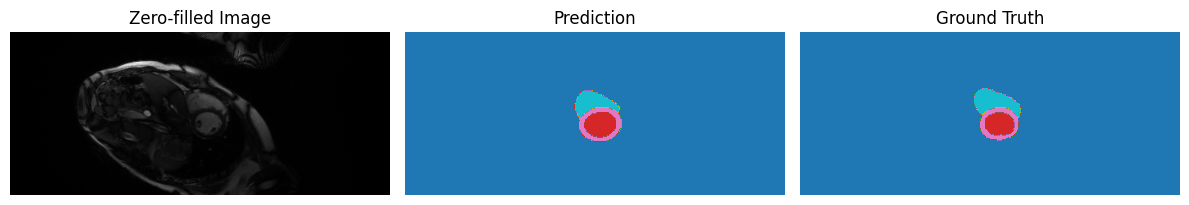

Evaluation Metrics:
Pixel Acc: 0.9871
mIoU: 0.6604
Mean Dice: 0.7724
IoU per class: [0.991 0.693 0.353 0.605]
Dice per class: [0.995 0.819 0.522 0.754]


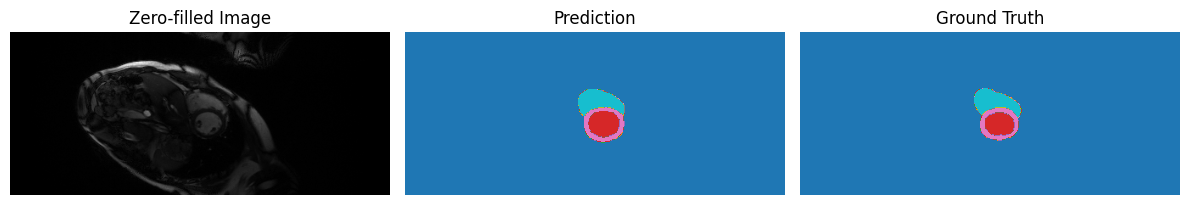

Evaluation Metrics:
Pixel Acc: 0.9948
mIoU: 0.8300
Mean Dice: 0.9011
IoU per class: [0.997 0.846 0.624 0.853]
Dice per class: [0.998 0.917 0.769 0.921]


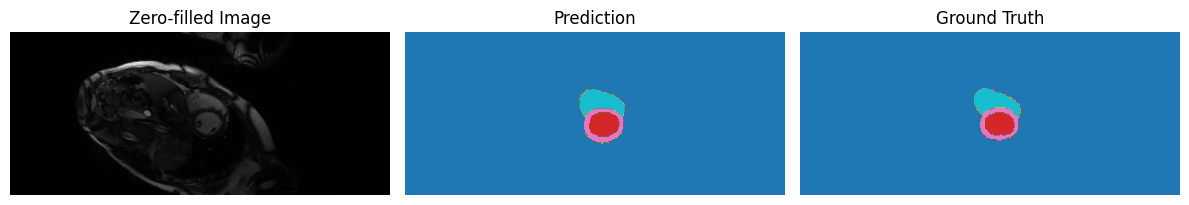

Evaluation Metrics:
Pixel Acc: 0.9957
mIoU: 0.8676
Mean Dice: 0.9254
IoU per class: [0.997 0.918 0.701 0.855]
Dice per class: [0.998 0.957 0.824 0.922]


In [6]:
vis(30)

Seg dataset size: 453 slices.


C:\Users\94557\AppData\Local\Temp\ipykernel_34108\1842234953.py:129: UserWarning: Glyph 21407 (\N{CJK UNIFIED IDEOGRAPH-539F}) missing from current font.
  plt.tight_layout(pad=1.1, w_pad=1.6, h_pad=0.6)
C:\Users\94557\AppData\Local\Temp\ipykernel_34108\1842234953.py:129: UserWarning: Glyph 22987 (\N{CJK UNIFIED IDEOGRAPH-59CB}) missing from current font.
  plt.tight_layout(pad=1.1, w_pad=1.6, h_pad=0.6)
C:\Users\94557\AppData\Local\Temp\ipykernel_34108\1842234953.py:129: UserWarning: Glyph 65288 (\N{FULLWIDTH LEFT PARENTHESIS}) missing from current font.
  plt.tight_layout(pad=1.1, w_pad=1.6, h_pad=0.6)
C:\Users\94557\AppData\Local\Temp\ipykernel_34108\1842234953.py:129: UserWarning: Glyph 24133 (\N{CJK UNIFIED IDEOGRAPH-5E45}) missing from current font.
  plt.tight_layout(pad=1.1, w_pad=1.6, h_pad=0.6)
C:\Users\94557\AppData\Local\Temp\ipykernel_34108\1842234953.py:129: UserWarning: Glyph 24230 (\N{CJK UNIFIED IDEOGRAPH-5EA6}) missing from current font.
  plt.tight_layout(pad=1.1, w_

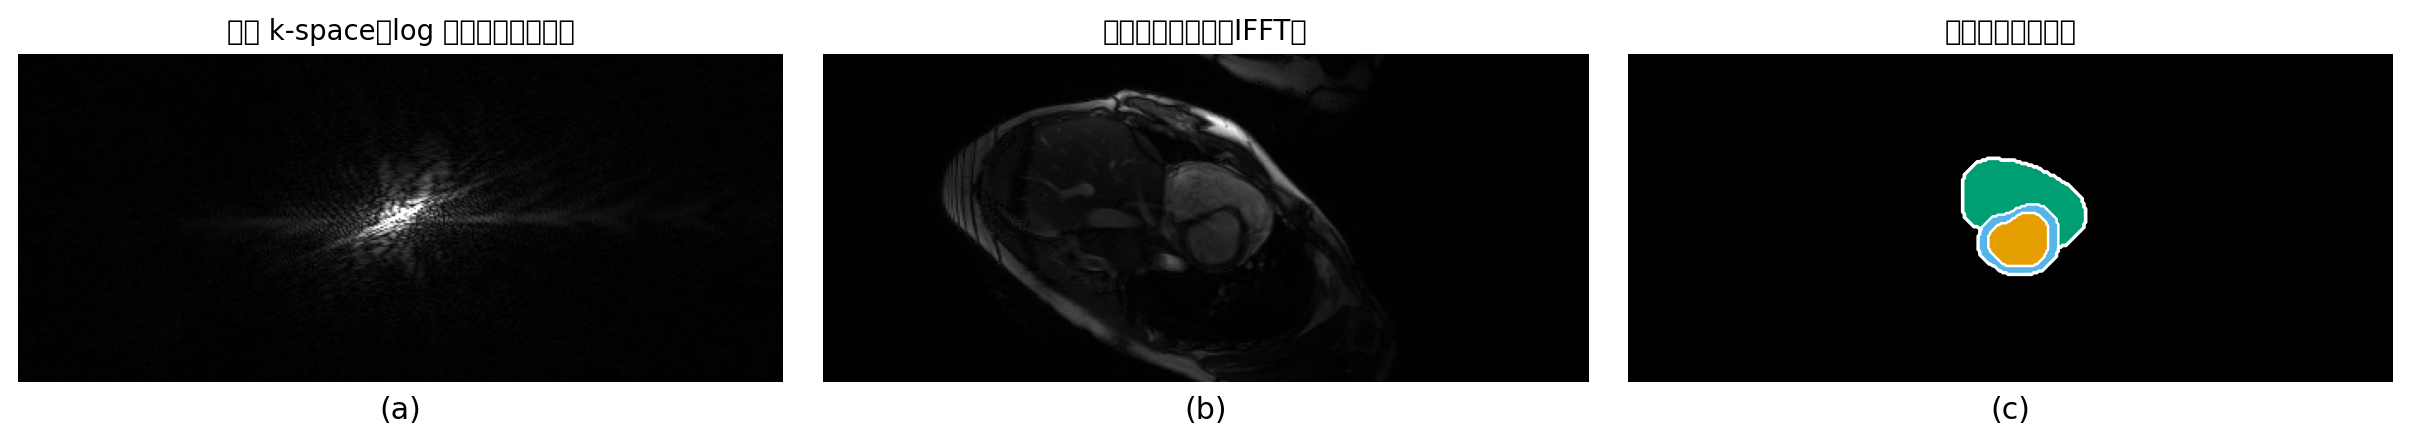

In [ ]:
import numpy as np
import h5py, nibabel as nib
import matplotlib.pyplot as plt
from pathlib import Path


def _ifft2c_np(k):
    return np.fft.ifftshift(
        np.fft.ifft2(np.fft.fftshift(k, axes=(-2, -1)), norm="ortho"),
        axes=(-2, -1)
    )

def _is_kspace_centered(kmag: np.ndarray, frac: float = 0.12) -> bool:
    H, W = kmag.shape
    h, w = max(2, int(H * frac)), max(2, int(W * frac))
    c0, c1 = H // 2 - h // 2, W // 2 - w // 2
    center_e = kmag[c0:c0 + h, c1:c1 + w].sum()

    corner_e = (kmag[:h, :w].sum() + kmag[:h, -w:].sum() +
                kmag[-h:, :w].sum() + kmag[-h:, -w:].sum())
    return center_e >= corner_e

from matplotlib import colors as mcolors

def get_seg_cmap(n_cls: int, bg="#F2F2F2"):
    base = ["#F2F2F2",
            "#E69F00", "#56B4E9", "#009E73", "#D55E00",
            "#CC79A7", "#0072B2", "#F0E442", "#000000"]
    if n_cls > len(base):
        extra = [mcolors.hsv_to_rgb((h, 0.75, 0.95)) for h in np.linspace(0, 1, n_cls-len(base), endpoint=False)]
        palette = base + [mcolors.to_hex(c) for c in extra]
    else:
        palette = base[:n_cls]
    cmap = mcolors.ListedColormap(palette)
    boundaries = np.arange(-0.5, n_cls + 0.5, 1)
    norm = mcolors.BoundaryNorm(boundaries, cmap.N)
    return cmap, norm, np.arange(n_cls)

def visualize_kspace_recon_and_label(
    dataset,
    index: int,
    coil_to_show: int = None,
    use_rss: bool = True,
    dpi: int = 180,
    save_path: str = None,
    p_low: float = 1.0,
    p_high: float = 99.9
):
    kfile, labfile, f = dataset.samples[index]

    with h5py.File(kfile, "r") as h:
        k = h["kspace_single_full"][()]
        if getattr(k, "dtype", None) is not None and k.dtype.names:
            k = k["real"] + 1j * k["imag"]

    kc = k[f][None, ...] if k.ndim == 3 else k[:, f]         # [C,H,W]
    C = min(getattr(dataset, "num_coil", kc.shape[0]), kc.shape[0])
    kc = kc[:C]
    kc = resize_kspace_complex(kc, dataset.tshape)            # [C,H,W]

    if coil_to_show is None:
        energies = np.linalg.norm(kc.reshape(kc.shape[0], -1), axis=1)
        coil_to_show = int(np.argmax(energies))
    else:
        coil_to_show = int(np.clip(coil_to_show, 0, kc.shape[0]-1))

    kmag0 = np.abs(kc[coil_to_show])
    is_centered = _is_kspace_centered(kmag0)

    k_for_show = kc[coil_to_show] if is_centered else np.fft.fftshift(kc[coil_to_show], axes=(-2, -1))
    mag = np.abs(k_for_show)
    p1, p99 = np.percentile(mag, [p_low, p_high])
    mag = np.clip(mag, p1, p99) - p1
    k_disp = np.log1p(mag)
    k_disp /= (k_disp.max() + 1e-12)

    img_per_coil = _ifft2c_np(kc)        # [C,H,W] complex
    if use_rss and img_per_coil.shape[0] > 1:
        img = np.sqrt(np.sum(np.abs(img_per_coil) ** 2, axis=0))
    else:
        img = np.abs(img_per_coil[0])

    seg = nib.load(str(labfile)).get_fdata()[:, :, f].T.astype(np.int16)
    seg = center_crop_or_pad(seg, dataset.tshape)
    seg[seg >= getattr(dataset, "ncls", 4)] = 0

    fig, axs = plt.subplots(1, 3, figsize=(13.5, 4.8), dpi=dpi)

    axs[0].imshow(k_disp, cmap="gray", vmin=0, vmax=1)
    axs[0].set_title("Raw k-space (log magnitude)" + (" [centered]" if is_centered else " [fftshift needed]"), fontsize=11)

    axs[1].imshow(img, cmap="gray")
    axs[1].set_title("Zero-filled reconstruction (IFFT)", fontsize=11)

    n_cls = getattr(dataset, "ncls", 4)
    cmap, norm, ticks = get_seg_cmap(n_cls, bg="#000000")
    axs[2].imshow(img, cmap="gray")
    axs[2].imshow(seg, cmap=cmap, norm=norm, interpolation="nearest", alpha=1)
    axs[2].contour(seg, levels=np.arange(0.5, n_cls, 1.0),
                    colors="white", linewidths=1.0)
    axs[2].set_title("Segmentation labels (overlay)", fontsize=11)
    

    for ax in axs:
        ax.set_xticks([]); ax.set_yticks([]); ax.set_frame_on(False)

    plt.tight_layout(pad=1.1, w_pad=1.6, h_pad=0.6)
    plt.subplots_adjust(bottom=0.14)
    fig.canvas.draw()
    for ax, tag in zip(axs, ["(a)", "(b)", "(c)"]):
        bb = ax.get_position()
        cx = 0.5 * (bb.x0 + bb.y0*0 + bb.x1)
        fig.text(cx, bb.y0 - 0.015, tag, ha="center", va="top", fontsize=12)

    plt.show()


device = torch.device(f"cuda:{args.gpu}" if torch.cuda.is_available() else "cpu")
cases = [f"P{str(i).zfill(3)}" for i in range(1, 60)]
val_cases = cases[::5]; train_cases = [c for c in cases if c not in val_cases]
frames = tuple(range(12))

train_ds = CineSegDataset(args.data_root, train_cases, frames,
                            tuple(args.target_shape), n_classes=args.n_classes)
visualize_kspace_recon_and_label(train_ds, index=0, coil_to_show=0, use_rss=True, dpi=180)